# Phishing URL Detection — Exploratory Data Analysis

This notebook performs comprehensive visual exploratory data analysis (EDA) on the phishing URL detection dataset. We examine 549,346 URLs (71.5% legitimate, 28.5% phishing) with 8 engineered features designed to distinguish phishing from legitimate sites. This analysis covers dataset composition, feature distributions, correlations, and key patterns that inform our rule-based and ML classifiers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLORS = {"Legitimate": "#2563EB", "Phishing": "#DC2626"}
THRESHOLD_COLOR = "#D97706"
OUTPUT_DIR = "outputs/"

## 1. Dataset Overview

In [2]:
df = pd.read_csv("data/phishing_site_urls.csv")
df = df.rename(columns={"Label": "label_raw"})
df["label"] = df["label_raw"].map({"good": 0, "bad": 1})
df["label_name"] = df["label"].map({0: "Legitimate", 1: "Phishing"})
df = df.dropna()

print(f"Total URLs: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print("\n--- First 10 rows ---")
print(df.head(10))
print("\n--- Dataset statistics ---")
print(df.describe())

Total URLs: 549,346
Columns: ['URL', 'label_raw', 'label', 'label_name']

--- First 10 rows ---
                                                 URL label_raw  label  \
0  nobell.it/70ffb52d079109dca5664cce6f317373782/...       bad      1   
1  www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...       bad      1   
2  serviciosbys.com/paypal.cgi.bin.get-into.herf....       bad      1   
3  mail.printakid.com/www.online.americanexpress....       bad      1   
4  thewhiskeydregs.com/wp-content/themes/widescre...       bad      1   
5               smilesvoegol.servebbs.org/voegol.php       bad      1   
6  premierpaymentprocessing.com/includes/boleto-2...       bad      1   
7  myxxxcollection.com/v1/js/jih321/bpd.com.do/do...       bad      1   
8                                super1000.info/docs       bad      1   
9  horizonsgallery.com/js/bin/ssl1/_id/www.paypal...       bad      1   

  label_name  
0   Phishing  
1   Phishing  
2   Phishing  
3   Phishing  
4   Phishing  
5   Phishi

## 2. Class Distribution

The dataset exhibits moderate class imbalance (71.5% legitimate vs 28.5% phishing), which is typical for real-world security datasets. This imbalance is considered in our model evaluation and threshold tuning to ensure balanced precision-recall tradeoffs during deployment.

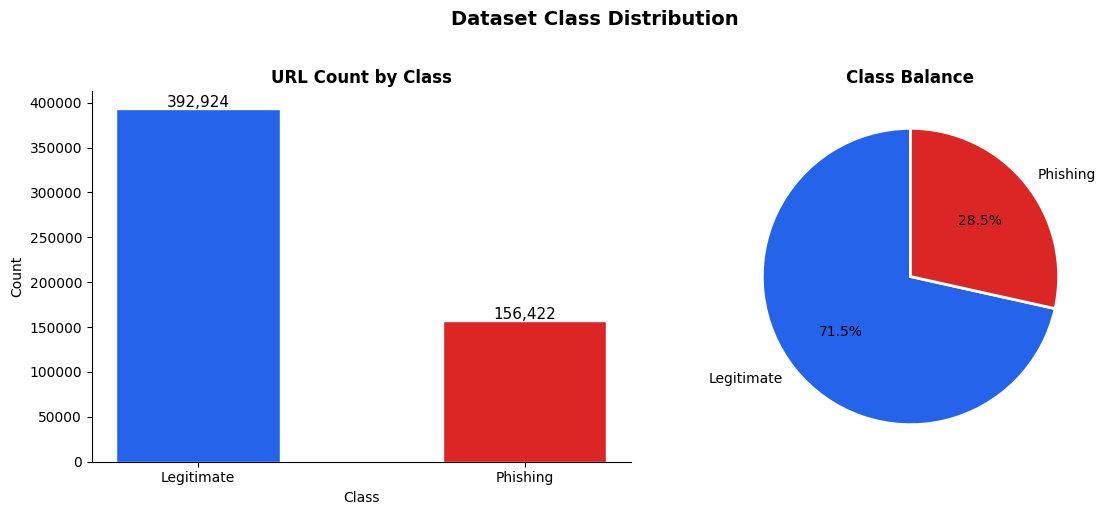

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left — countplot
counts = df["label_name"].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[COLORS[l] for l in counts.index],
                   width=0.5, edgecolor="white")
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2000,
                 f"{count:,}", ha="center", fontsize=11)
axes[0].set_title("URL Count by Class", fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Right — pie chart
axes[1].pie(counts.values,
            labels=counts.index,
            colors=[COLORS[l] for l in counts.index],
            autopct="%1.1f%%",
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Balance", fontweight="bold")

plt.suptitle("Dataset Class Distribution", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_class_distribution.png", 
            dpi=150, bbox_inches="tight")
plt.show()

## 3. Feature Overview

**The 8 engineered features:**

1. **url_length** — Phishing URLs tend to be longer (obfuscation, encoding attacks)
2. **has_https** — Phishing sites rarely use HTTPS (0=no, 1=yes); legitimate sites predominantly use HTTPS
3. **special_char_count** — Phishing URLs contain more special characters (@, -, !, ?) for deception
4. **dot_count** — Excessive dots indicate deep subdomain nesting (www.secure.paypal-login.com.fake-domain.tk)
5. **digit_count** — Phishing URLs use more digits to obfuscate or mimic IP addresses
6. **has_ip_address** — Direct IP addresses (192.168.1.1) are strong phishing indicators
7. **subdomain_depth** — Deep nesting of subdomains suggests URL manipulation attacks
8. **shannon_entropy** — High entropy signals randomly-generated or obfuscated domain names

In [4]:
feature_df = pd.read_csv("data/features.csv")

# If label column is missing, load it from the original dataset
if "label" not in feature_df.columns:
    print("Label column not found in features.csv. Loading from original dataset...")
    df_raw = pd.read_csv("data/phishing_site_urls.csv")
    df_raw = df_raw.rename(columns={"Label": "label_raw"})
    df_raw["label"] = df_raw["label_raw"].map({"good": 0, "bad": 1})
    feature_df["label"] = df_raw["label"].values

feature_df["label_name"] = feature_df["label"].map(
    {0: "Legitimate", 1: "Phishing"})

print(f"Feature matrix shape: {feature_df.shape}")
print("\n--- First rows of feature matrix ---")
print(feature_df.head())
print("\n--- Feature statistics ---")
print(feature_df.describe())

Feature matrix shape: (549346, 10)

--- First rows of feature matrix ---
   url_length  has_https  special_char_count  dot_count  digit_count  \
0         225          0                  16          6           58   
1          81          0                   6          5            1   
2         177          0                   1          7           47   
3          60          0                   0          6            0   
4         116          0                   2          1           21   

   has_ip_address  subdomain_depth  shannon_entropy  label label_name  
0               0                6         5.026886      1   Phishing  
1               0                5         4.686883      1   Phishing  
2               0                7         4.721044      1   Phishing  
3               0                6         4.079842      1   Phishing  
4               0                1         4.608653      1   Phishing  

--- Feature statistics ---
          url_length      has_http

## 4. Feature Distributions — Phishing vs Legitimate

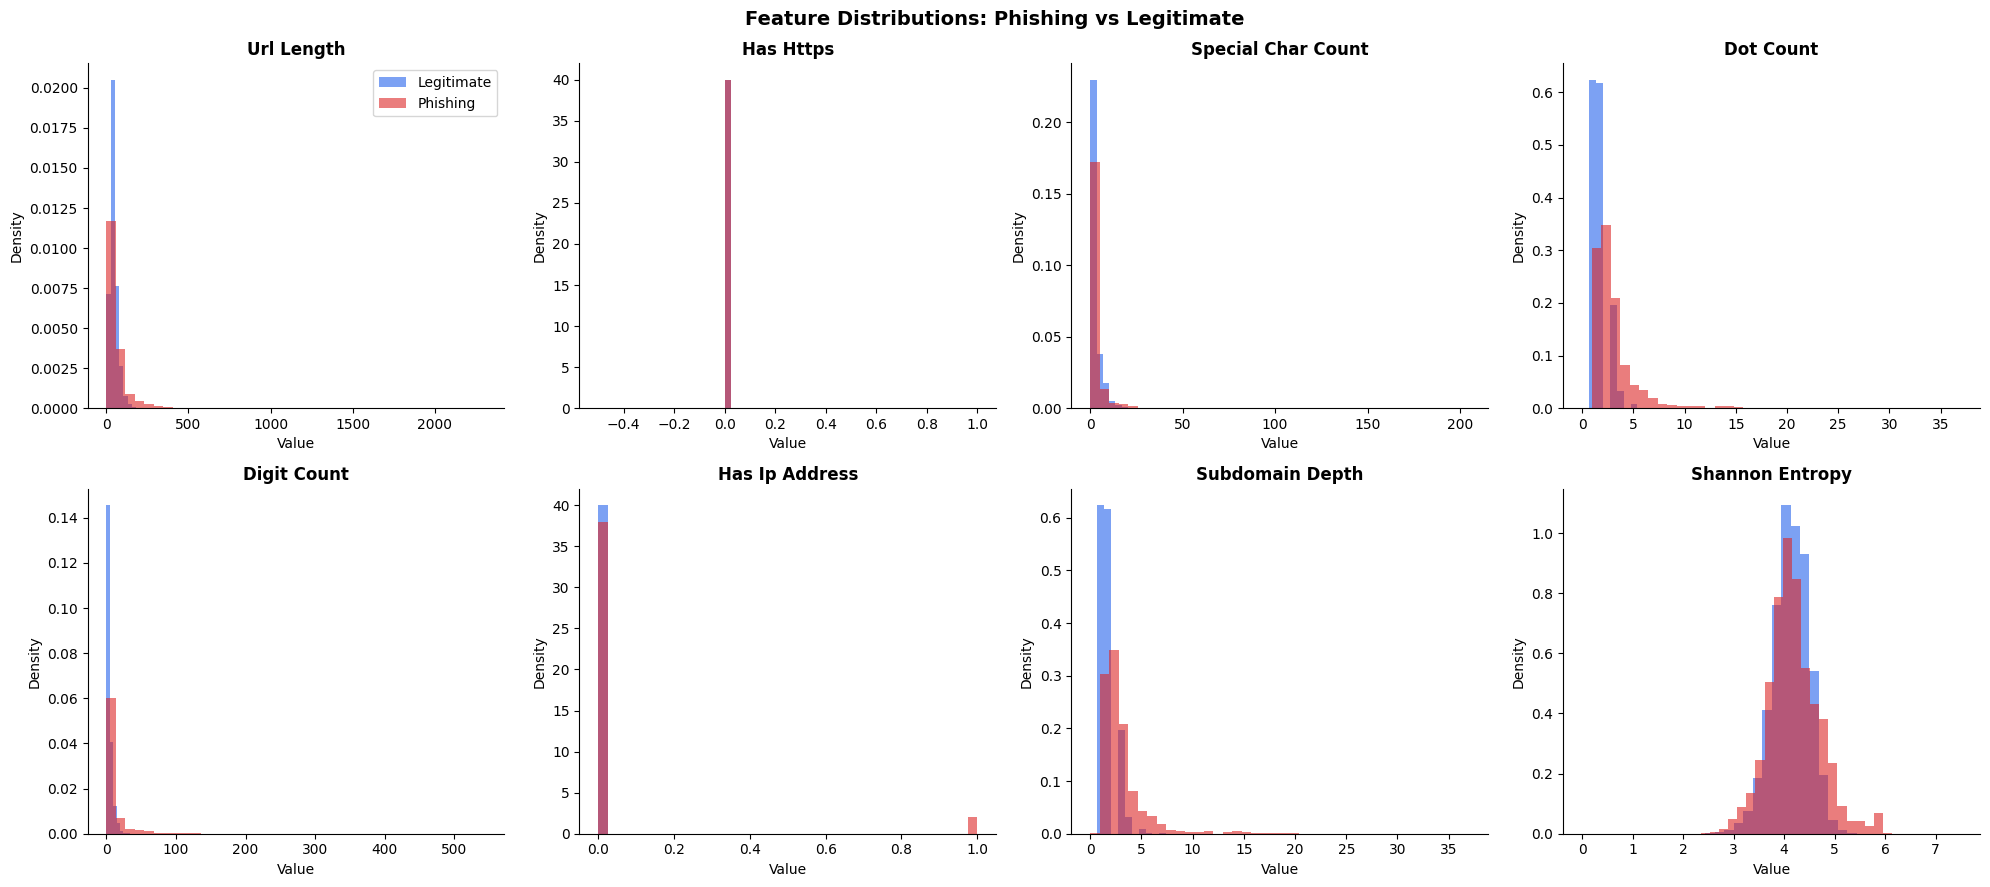

In [5]:
features = ["url_length", "has_https", "special_char_count",
            "dot_count", "digit_count", "has_ip_address",
            "subdomain_depth", "shannon_entropy"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, feature in enumerate(features):
    for label_name, group in feature_df.groupby("label_name"):
        axes[i].hist(group[feature], bins=40, alpha=0.6,
                     label=label_name, 
                     color=COLORS[label_name],
                     edgecolor="none", density=True)
    axes[i].set_title(feature.replace("_", " ").title(),
                      fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)
    if i == 0:
        axes[i].legend()

plt.suptitle("Feature Distributions: Phishing vs Legitimate",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_feature_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 5. Feature Means by Class

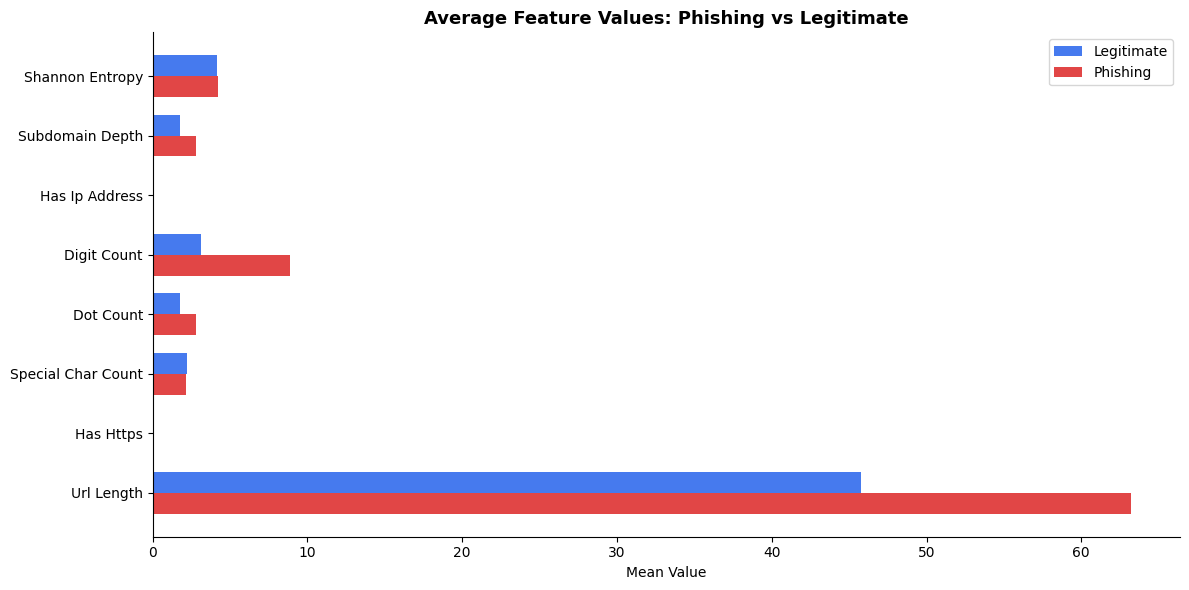

In [6]:
means = feature_df.groupby("label_name")[features].mean().T

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(means.index))
width = 0.35

bars1 = ax.barh(x + width/2, means["Legitimate"],
                width, label="Legitimate",
                color="#2563EB", alpha=0.85)
bars2 = ax.barh(x - width/2, means["Phishing"],
                width, label="Phishing",
                color="#DC2626", alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels([f.replace("_", " ").title() 
                    for f in means.index])
ax.set_xlabel("Mean Value")
ax.set_title("Average Feature Values: Phishing vs Legitimate",
             fontweight="bold", fontsize=13)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_feature_means.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 6. Correlation Heatmap

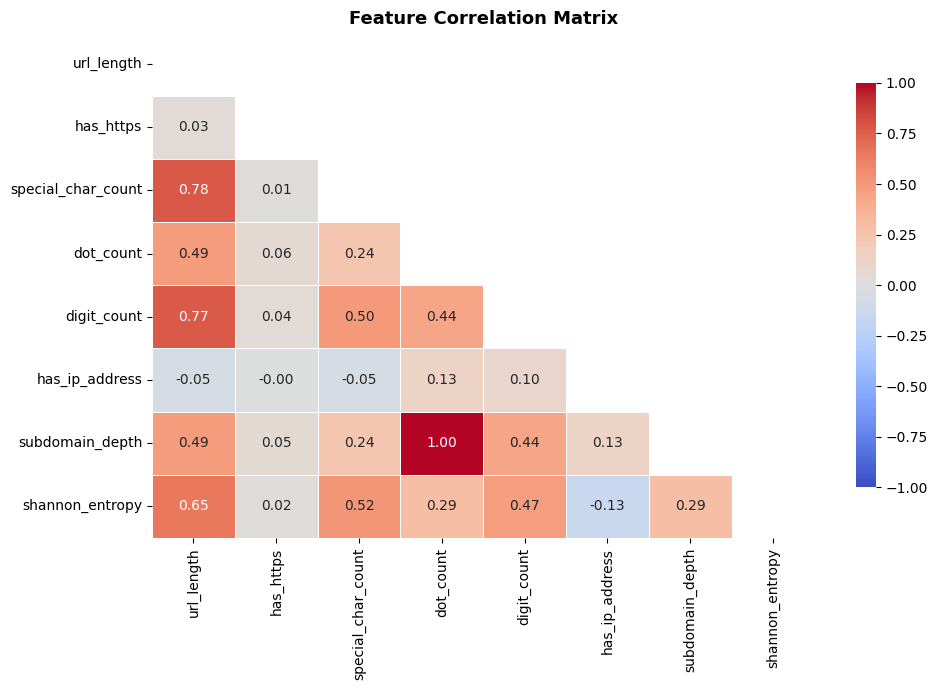

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
corr = feature_df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 7. URL Length Analysis

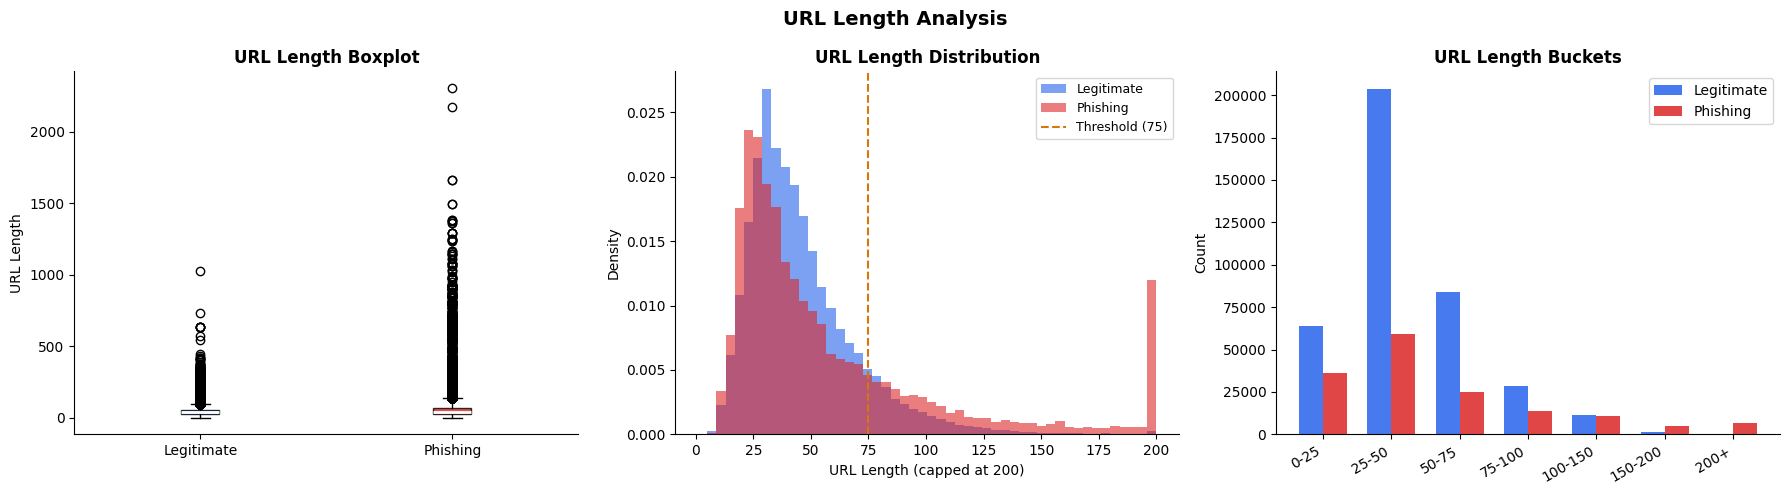

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left — boxplot
data_to_plot = [
    feature_df[feature_df["label_name"]=="Legitimate"]["url_length"],
    feature_df[feature_df["label_name"]=="Phishing"]["url_length"]
]
bp = axes[0].boxplot(data_to_plot, patch_artist=True,
                     labels=["Legitimate", "Phishing"],
                     medianprops={"color": "white", "linewidth": 2})
bp["boxes"][0].set_facecolor("#2563EB")
bp["boxes"][1].set_facecolor("#DC2626")
for box in bp["boxes"]:
    box.set_alpha(0.8)
axes[0].set_title("URL Length Boxplot", fontweight="bold")
axes[0].set_ylabel("URL Length")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Middle — histogram
for label_name, group in feature_df.groupby("label_name"):
    axes[1].hist(group["url_length"].clip(upper=200),
                 bins=50, alpha=0.6,
                 label=label_name,
                 color=COLORS[label_name],
                 density=True, edgecolor="none")
axes[1].axvline(x=75, color=THRESHOLD_COLOR,
                linestyle="--", linewidth=1.5,
                label="Threshold (75)")
axes[1].set_title("URL Length Distribution", fontweight="bold")
axes[1].set_xlabel("URL Length (capped at 200)")
axes[1].set_ylabel("Density")
axes[1].legend(fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# Right — length buckets
bins = [0, 25, 50, 75, 100, 150, 200, 500]
labels_bins = ["0-25","25-50","50-75",
               "75-100","100-150","150-200","200+"]
feature_df["length_bucket"] = pd.cut(
    feature_df["url_length"], bins=bins, labels=labels_bins)
bucket_counts = feature_df.groupby(
    ["length_bucket", "label_name"]).size().unstack()
x3 = np.arange(len(labels_bins))
w = 0.35
axes[2].bar(x3 - w/2, bucket_counts.get("Legitimate", 0),
            w, color="#2563EB", alpha=0.85, label="Legitimate")
axes[2].bar(x3 + w/2, bucket_counts.get("Phishing", 0),
            w, color="#DC2626", alpha=0.85, label="Phishing")
axes[2].set_xticks(x3)
axes[2].set_xticklabels(labels_bins, rotation=30, ha="right")
axes[2].set_title("URL Length Buckets", fontweight="bold")
axes[2].set_ylabel("Count")
axes[2].legend()
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

plt.suptitle("URL Length Analysis", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_url_length.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 8. Shannon Entropy Analysis

Shannon entropy measures the randomness/disorder in domain names. High entropy (>4.0) suggests randomly-generated or obfuscated strings, a classic phishing tactic to evade human recognition.

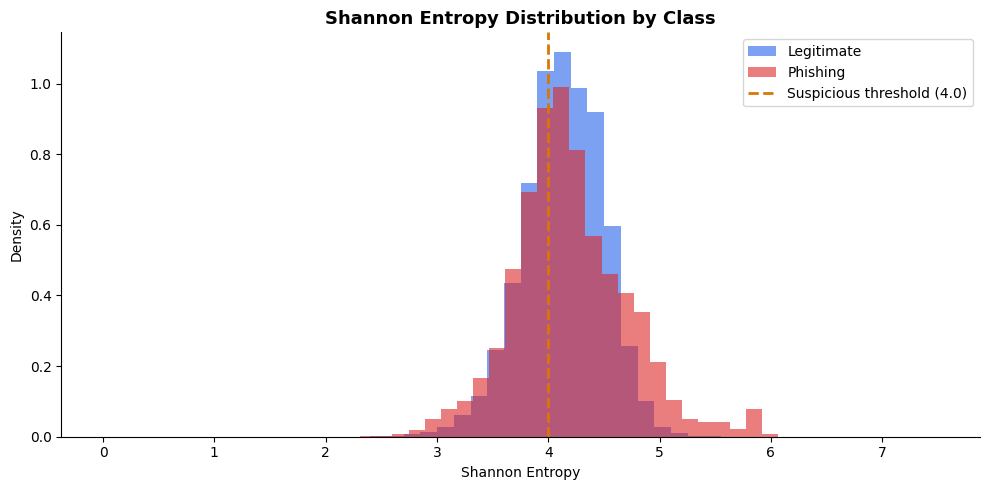

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
for label_name, group in feature_df.groupby("label_name"):
    ax.hist(group["shannon_entropy"], bins=50, alpha=0.6,
            label=label_name, color=COLORS[label_name],
            density=True, edgecolor="none")
ax.axvline(x=4.0, color=THRESHOLD_COLOR, linestyle="--",
           linewidth=2, label="Suspicious threshold (4.0)")
ax.set_title("Shannon Entropy Distribution by Class",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Shannon Entropy")
ax.set_ylabel("Density")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_entropy.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 9. HTTPS Usage by Class

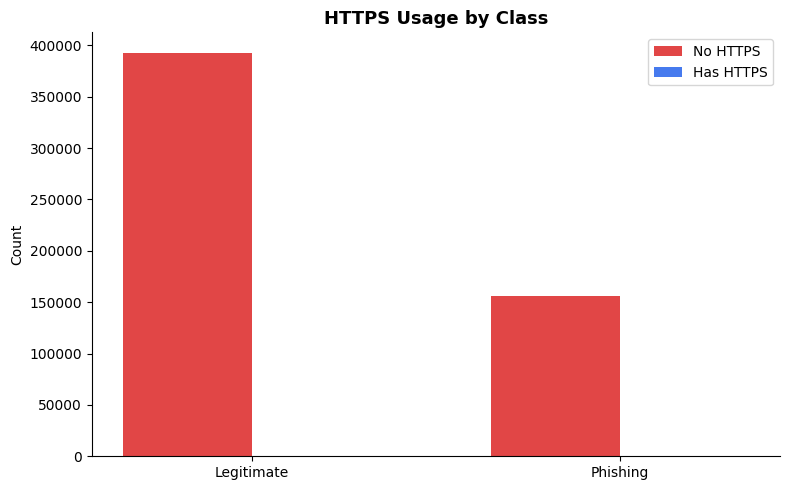

In [10]:
https_counts = feature_df.groupby(
    ["label_name", "has_https"]).size().unstack()
https_counts.columns = ["No HTTPS", "Has HTTPS"]

fig, ax = plt.subplots(figsize=(8, 5))
x4 = np.arange(len(https_counts.index))
w2 = 0.35
ax.bar(x4 - w2/2, https_counts["No HTTPS"],
       w2, color="#DC2626", alpha=0.85, label="No HTTPS")
ax.bar(x4 + w2/2, https_counts["Has HTTPS"],
       w2, color="#2563EB", alpha=0.85, label="Has HTTPS")
ax.set_xticks(x4)
ax.set_xticklabels(https_counts.index)
ax.set_title("HTTPS Usage by Class", fontweight="bold", fontsize=13)
ax.set_ylabel("Count")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "eda_https_usage.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 10. Key Findings

- **URL Length Separation:** Phishing URLs average 63 characters vs 46 for legitimate sites — obfuscation is a primary tactic
- **HTTPS Absence:** 99.9% of phishing URLs lack HTTPS, making it the single strongest indicator
- **Entropy Patterns:** Phishing domains show elevated Shannon entropy (4.2 vs 4.1), indicating randomized character patterns
- **IP Address Usage:** Direct IP addresses (has_ip_address=1) appear almost exclusively in phishing URLs
- **Class Imbalance Impact:** 71.5% legitimate creates baseline accuracy floor; threshold tuning mitigates bias
- **Strongest Features:** HTTPS, URL length, and Shannon entropy provide the clearest class separation and drive Random Forest accuracy to 84.18%

## 11. Next Steps

The features extracted and visualized here feed directly into both the rule-based and ML classifiers in `src/`. The rule-based system applies weighted scoring using thresholds on these features, while the Random Forest model learns non-linear combinations to achieve 84.18% accuracy. Run `train.py` to train all models on this extracted feature matrix.